In [64]:
# import libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression , Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Display all columns (don't truncate)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)


In [65]:
df = pd.read_csv('D:/AI&ML/projects/claude/linear_regression/files/train.csv')
print(df.shape)
print(f'Num Of Rows : {df.shape[0]}')
print(f'Num Of columns : {df.shape[1]}')

(1460, 81)
Num Of Rows : 1460
Num Of columns : 81


In [66]:
df.head(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [67]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [68]:
print('counts for each data types')
print(df.dtypes.value_counts())
print()
df.info()

counts for each data types
object     43
int64      35
float64     3
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  

In [69]:
print('Statistics Info For numerical Columns')
df.describe().T

Statistics Info For numerical Columns


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [70]:
print('Statistics Info For TEXT Columns')
df.describe(include='object').T

Statistics Info For TEXT Columns


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [71]:
# num of numerical features and categorical features
print(f'num of numerical feature {df.select_dtypes(include=['number']).shape[1]}')
print(f'num of categorical feature {df.select_dtypes(include=['object']).shape[1]}')

num of numerical feature 38
num of categorical feature 43


In [72]:
# Check missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame(
    {
        'missing_count' : missing_count,
        'missing_percent (%)' : missing_percent.round(2)
    }
)

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['missing_count'] > 0]
missing_df = missing_df.sort_values('missing_percent (%)', ascending=False)

print('=========== Missing Values ===========')
print(f'total column with missing values : {len(missing_df)}')
print(missing_df)

=========== Missing Values ===========
total column with missing values : 19
              missing_count  missing_percent (%)
PoolQC                 1453                99.52
MiscFeature            1406                96.30
Alley                  1369                93.77
Fence                  1179                80.75
MasVnrType              872                59.73
FireplaceQu             690                47.26
LotFrontage             259                17.74
GarageType               81                 5.55
GarageYrBlt              81                 5.55
GarageFinish             81                 5.55
GarageQual               81                 5.55
GarageCond               81                 5.55
BsmtExposure             38                 2.60
BsmtFinType2             38                 2.60
BsmtQual                 37                 2.53
BsmtCond                 37                 2.53
BsmtFinType1             37                 2.53
MasVnrArea                8              

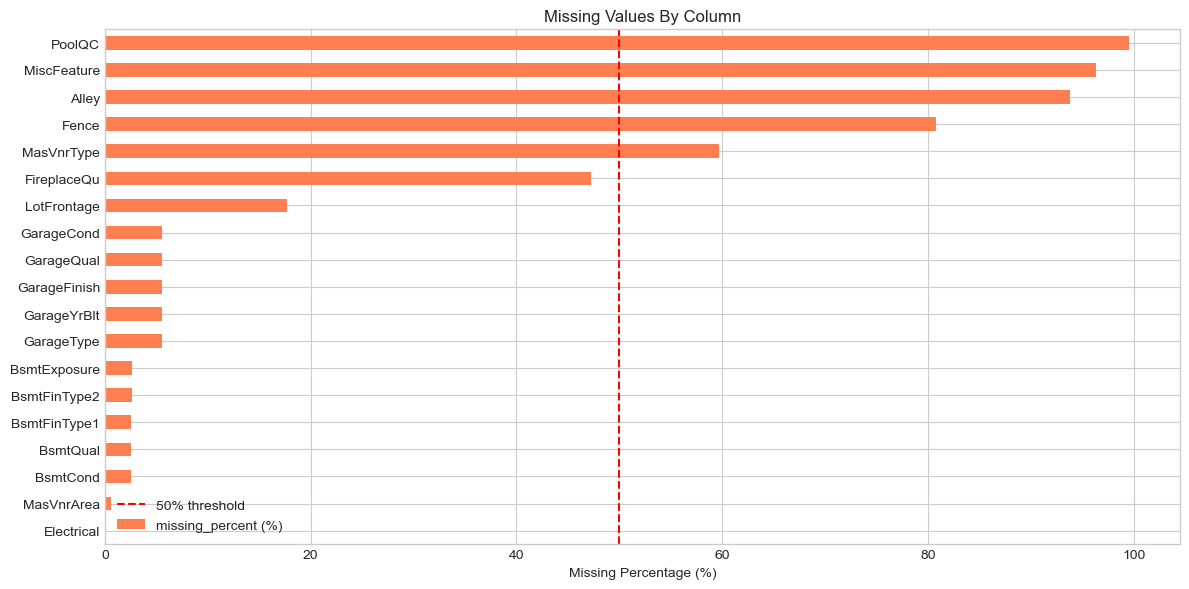

Columns with > 50% missing (candidate for dropping) : 
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


In [73]:
# Visualize Missing values as a bar chart
if len(missing_df) > 0 :
    plt.figure(figsize = (12, 6))
    missing_df['missing_percent (%)'].sort_values().plot(kind = 'barh', color='coral')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values By Column')
    plt.axvline(x=50, color='red', linestyle='--', label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('Columns with > 50% missing (candidate for dropping) : ')
    print(missing_df[missing_df['missing_percent (%)'] > 50 ].index.tolist())

In [74]:
# check duplicates
print(f'Duplicate Rows : {df.duplicated().sum()}')
# drop duplicates if exist
df = df.drop_duplicates()
print(f'Shape After drop Duplicated Rows : {df.shape}')

Duplicate Rows : 0
Shape After drop Duplicated Rows : (1460, 81)


In [75]:
# Analyze Target (SalePrice)
target_col = 'SalePrice'
print(f'Min              : ${df[target_col].min():,.0f}')
print(f'Max              : ${df[target_col].max():,.0f}')
print(f'Mean             : ${df[target_col].mean():,.0f}')
print(f'Median           : ${df[target_col].median():,.0f}')
print(f'Std              : ${df[target_col].std():,.0f}')
print(f'Skewness         :  ${df[target_col].skew():.2f}')

Min              : $34,900
Max              : $755,000
Mean             : $180,921
Median           : $163,000
Std              : $79,443
Skewness         :  $1.88


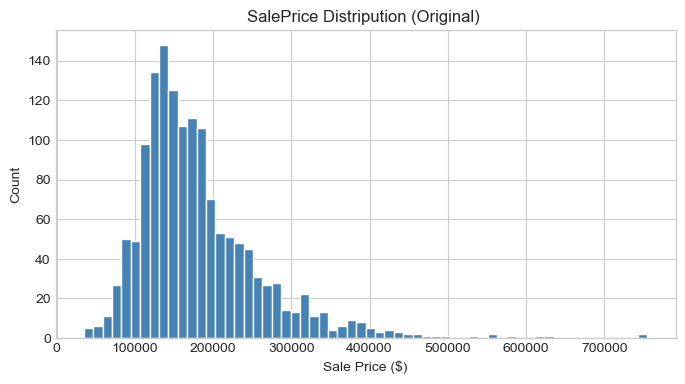

In [76]:
# plot the distripution of house prices

plt.figure(figsize=(8, 4))
plt.hist(df[target_col], bins=60, color='steelblue', edgecolor='white')
plt.title('SalePrice Distripution (Original) ')
plt.xlabel('Sale Price ($)')
plt.ylabel('Count')
plt.show()

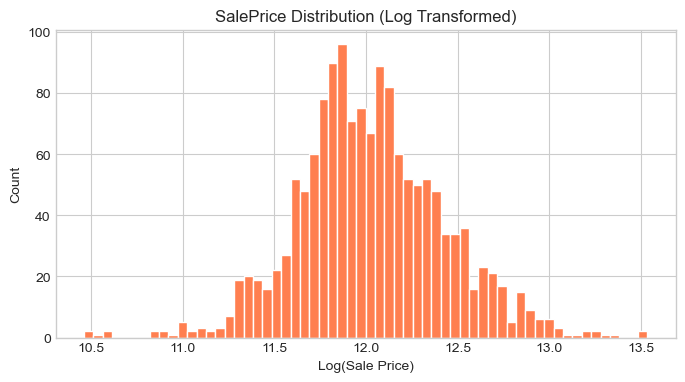

In [77]:
# Right plot: Log-transformed distribution

# Why log? Because prices are right-skewed (a few very expensive houses).
# Log makes it more symmetric. Linear regression works better with
# a symmetric (normal-looking) target.

plt.figure(figsize=(8,4))
plt.hist(np.log1p(df[target_col]), bins=60, color='coral', edgecolor='white')
plt.title('SalePrice Distribution (Log Transformed)')
plt.xlabel('Log(Sale Price)')
plt.ylabel('Count')
plt.show()

In [78]:
# NOTICE: The log-transformed version looks more (normal)
# Apply log transformation to target
df['LogSalePrice'] = np.log1p(df[target_col])
print(df['LogSalePrice'])

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: LogSalePrice, Length: 1460, dtype: float64


In [79]:
# Statistics for target after log_trasformed
print(f'Min              :  ${df['LogSalePrice'].min():.2f}')
print(f'Max              :  ${df['LogSalePrice'].max():.2f}')
print(f'Mean             :  ${df['LogSalePrice'].mean():.2f}')
print(f'Median           :  ${df['LogSalePrice'].median():.2f}')
print(f'Std              :  ${df['LogSalePrice'].std():.2f}')
print(f'Skewness         :  ${df['LogSalePrice'].skew():.2f}')

Min              :  $10.46
Max              :  $13.53
Mean             :  $12.02
Median           :  $12.00
Std              :  $0.40
Skewness         :  $0.12


------------- Top 15 Features Correlated To Sale Price ---------------
SalePrice       0.948374
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Fireplaces      0.489450
MasVnrArea      0.430809
BsmtFinSF1      0.372023
Name: LogSalePrice, dtype: float64


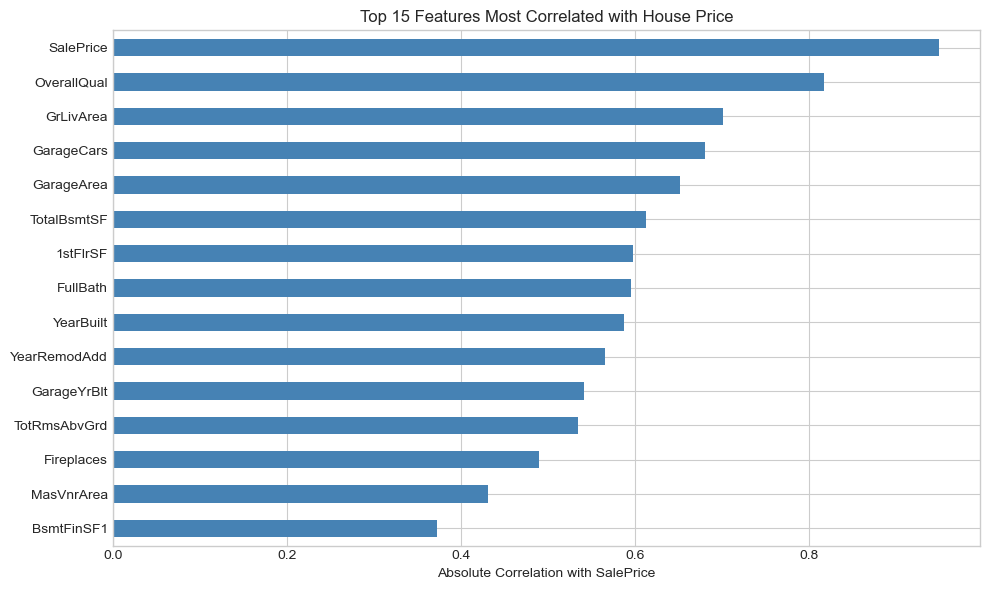

In [80]:
# look at correlation with the target
# for numerical features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corr()['LogSalePrice'].drop('LogSalePrice')
correlations = correlations.abs().sort_values(ascending=False)
print('------------- Top 15 Features Correlated To Sale Price ---------------')
print(correlations.head(15))

# visualize top correlation
plt.figure(figsize=(10, 6))
correlations.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Correlation with SalePrice')
plt.title('Top 15 Features Most Correlated with House Price')
plt.tight_layout()
plt.show()

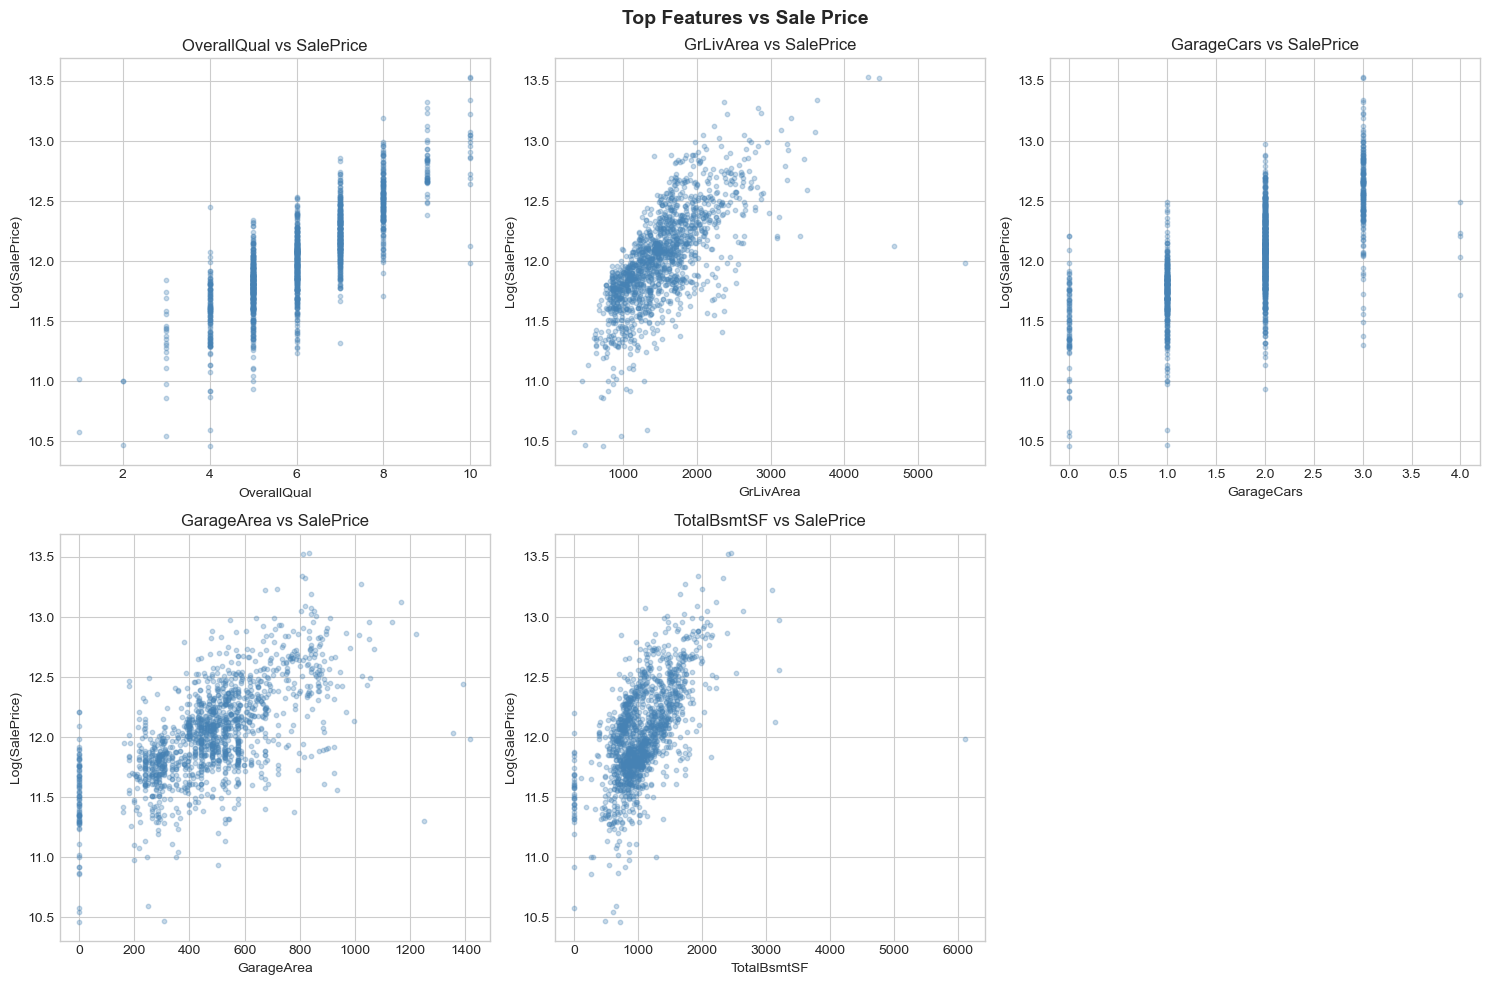

In [81]:
# Scatter plots for top correlated features
# visualize the relationship between top features and price
top_features = correlations.head(6).index.tolist()
# Remove the original SalePrice if it appears 
top_features = [f for f in top_features if f != target_col]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_features[:6]) : 
    plt.subplot(2, 3, i+1)
    plt.scatter(df[feature], df['LogSalePrice'], alpha=0.3, color='steelblue', s=10)
    plt.xlabel(feature)
    plt.ylabel('Log(SalePrice)')
    plt.title(f'{feature} vs SalePrice')

plt.suptitle('Top Features vs Sale Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

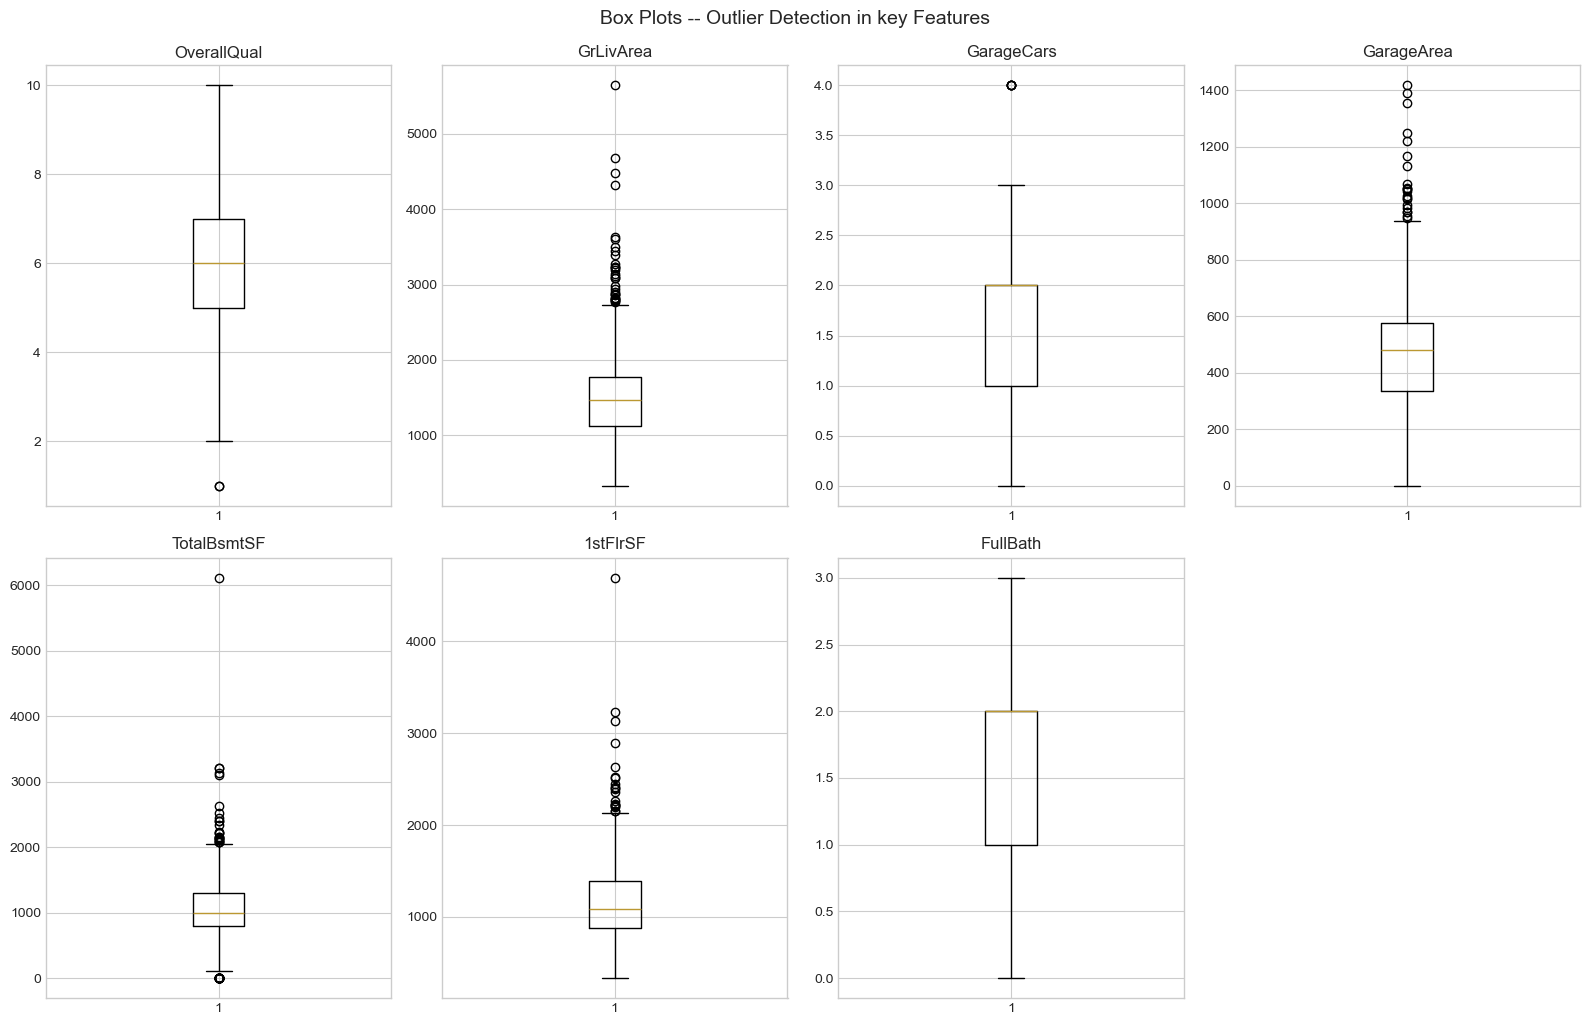

In [82]:
# Detect outlier in key numeric features 
key_numeric = correlations.head(8).index.tolist()
key_numeric = [f for f in key_numeric if f != target_col and f in df.columns]
plt.figure(figsize=(16, 10))
for i, col in enumerate(key_numeric) : 
    plt.subplot(2, 4, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.tight_layout()

plt.suptitle('Box Plots -- Outlier Detection in key Features', fontsize=14, y=1.02)
plt.show()

In [83]:
# Data Preprocessing
'''
1- Drop useless columns
2- Fix data types
3- Handle missing values
4- Handle outliers
5- Encode categorical columns
6- Select features
7- Split train/test
8- Scale features
'''

'\n1- Drop useless columns\n2- Fix data types\n3- Handle missing values\n4- Handle outliers\n5- Encode categorical columns\n6- Select features\n7- Split train/test\n8- Scale features\n'

In [84]:
# Drop irrelevant and proplematic columns
# make a copy
df_clean = df.copy()
# Drop Id column
cols_to_drop = []

for col in df_clean.columns :
    if col.lower() in ['id', 'pid', 'order'] :
        cols_to_drop.append(col)

# Drop columns with more 50% missing values
missing_pct = df_clean.isnull().mean()
high_missing = missing_pct[missing_pct > 0.50].index.tolist()
cols_to_drop.extend(high_missing)

# Remove duplicates from the drop list
cols_to_drop = list(set(cols_to_drop))

print(f'columns to drop : {cols_to_drop}')
df_clean = df_clean.drop(columns = cols_to_drop, errors='ignore')
print(f'Shape after dropping : {df_clean.shape}')

columns to drop : ['Alley', 'Fence', 'MasVnrType', 'Id', 'MiscFeature', 'PoolQC']
Shape after dropping : (1460, 76)


In [85]:
# separate numeric and categorical columns
# target column
target = 'LogSalePrice'
# Remove target and original price from feature list 
exclude = [target_col, target, 'LogSalePrice']

# Get Columns type
numeric_features = df_clean.select_dtypes(include=['number']).columns.tolist()
categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric Features : {len(numeric_features)}')
print(f'Categorical Features : {len(categorical_features)}')
print(f'\n Numeric {numeric_features}')
print(f'\n Categorical {categorical_features}')

Numeric Features : 38
Categorical Features : 38

 Numeric ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'LogSalePrice']

 Categorical ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Func

In [86]:
# Handle Missing values in numeric columns
# fill with median (robust to outliers)

num_missing = df_clean[numeric_features].isnull().sum()
print(f'Num Of Missing valeues : \n{num_missing[num_missing > 0]}')

for col in numeric_features :
    if df_clean[col].isnull().sum() > 0 :
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'Filled {col} missing values with median = {median_val:.2f}')
        

Num Of Missing valeues : 
LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64
Filled LotFrontage missing values with median = 69.00
Filled MasVnrArea missing values with median = 0.00
Filled GarageYrBlt missing values with median = 1980.00


In [87]:
# Handle Missing values in categorical columns
#   - If missing means "not present" → fill with 'None'
#   - Otherwise → fill with Mode (most common value)
# these columns have nan because the feature doesn't exist
non_fill_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual',
                  'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                 'Fence', 'MiscFeature', 'Alley', 'PoolQc', 'MasVnrType'
                ]

for col in non_fill_cols :
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0 :
        df_clean[col] = df_clean[col].fillna('None')
        print(f'Filled {col} with "None" ')

print('=====================================================')
# fill other categorical columns with mode 
for col in categorical_features :
    if df_clean[col].isnull().sum() > 0 :
        mode_val = df_clean[col].mode()[0] 
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f'Filled {col} With mode value  = {mode_val}')

total_missing = df_clean.isnull().sum().sum()
print(f'Total Missing = {total_missing}')

Filled GarageType with "None" 
Filled GarageFinish with "None" 
Filled GarageQual with "None" 
Filled GarageCond with "None" 
Filled BsmtQual with "None" 
Filled BsmtCond with "None" 
Filled BsmtExposure with "None" 
Filled BsmtFinType1 with "None" 
Filled BsmtFinType2 with "None" 
Filled FireplaceQu with "None" 
Filled Electrical With mode value  = SBrkr
Total Missing = 0


In [88]:
# Handle Outliers in key numeric features using IQR

def remove_outliers_iqr(dataframe, column, factor=2.5) :
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    mask = (dataframe[column] >= lower) & (dataframe[column] <= upper)
    removed = (~mask).sum()
    if removed > 0:
        print(f' Removed {removed} outliers from {column}')
    return dataframe[mask]

before = len(df_clean)
# Apply outlier remover to the most important features + target
important_for_outliers =  ['Gr Liv Area', 'Total Bsmt SF', 'GrLivArea', 'TotalBsmtSF',
                           'Lot Area', 'LotArea', '1st Flr SF', '1stFlrSF']

for col in important_for_outliers:
    if col in df_clean.columns:
        df_clean = remove_outliers_iqr(df_clean, col)

# Remove outlier from target
df_clean = remove_outliers_iqr(df_clean, 'LogSalePrice', factor = 3)
after = len(df_clean)
    
print(f'\n Rows before : {before}, after : {after}, removed : {before - after}')

 Removed 9 outliers from GrLivArea
 Removed 4 outliers from TotalBsmtSF
 Removed 40 outliers from LotArea
 Removed 1 outliers from 1stFlrSF

 Rows before : 1460, after : 1406, removed : 54


In [89]:
# Feature Engineering 

# Age of house when sold
if 'Year Built' in df_clean.columns:
    yr_col = 'Year Built'
elif 'YearBuilt' in df_clean.columns:
    yr_col = 'YearBuilt'
else:
    yr_col = None

sold_col = None

if 'Yr Sold' in df_clean.columns:
    sold_col = 'Yr Sold'
elif 'YrSold' in df_clean.columns:
    sold_col = 'YrSold'

if yr_col and sold_col:
    df_clean['HouseAge'] = df_clean['YrSold'] - df_clean['YearBuilt']
    df_clean['HouseAge'] = df_clean['HouseAge'].clip(lower=0)
    print(f'Created HouseAge from YearSold and YearBuilt ')
    numeric_features.append('HouseAge')
    
# total square footage (basement + above ground)
bsmt_col = 'TotalBsmtSF' if 'TotalBsmtSF' in df_clean.columns else 'Total Bsmt SF'
grnd_col = 'GrLivArea' if 'GrLivArea' in df_clean.columns else 'Gr Liv Area'

if bsmt_col in df_clean.columns and grnd_col in df_clean.columns : 
    df_clean['TotalSF'] = df_clean[bsmt_col] + df_clean[grnd_col]
    print('Created "TotalSF" (total square footage)')
    numeric_features.append('TotalSF')

print('\n New features added!')


Created HouseAge from YearSold and YearBuilt 
Created "TotalSF" (total square footage)

 New features added!


In [90]:
# Encode Categorical variables using one-Hot Encoding

categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical features to encode : {len(categorical_features)}')
# Drop categories with too many unique values (they create too many columns)
# keep those with <= 15 unique values 

cat_to_encode = []
cat_to_drop = []

for col in categorical_features :
    nunique = df_clean[col].nunique()
    if nunique <= 15:
        cat_to_encode.append(col)
    else : 
        cat_to_drop.append(col)
        print(f'  Dropping "{col}" — {nunique} unique values (too many)')

df_clean = df_clean.drop(columns = cat_to_drop)
print(f'\nEncoding {len(cat_to_encode)} categorical columns...')


# Apply One-Hot Encoding
# drop_first=True: removes one dummy to avoid multicollinearity
df_encoded = pd.get_dummies(df_clean, columns=cat_to_encode, drop_first=True)

print(f'Shape before encoding: {df_clean.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')
print(f'New columns created: {df_encoded.shape[1] - df_clean.shape[1]}')

Categorical features to encode : 38
  Dropping "Neighborhood" — 25 unique values (too many)
  Dropping "Exterior2nd" — 16 unique values (too many)

Encoding 36 categorical columns...
Shape before encoding: (1406, 76)
Shape after encoding:  (1406, 206)
New columns created: 130


In [91]:
# Select Features and target
# Target
y = df_encoded['LogSalePrice']

# Features
drop_from_X = [target_col, 'LogSalePrice']
drop_from_X = [c for c in drop_from_X if c in df_encoded.columns]

X = df_encoded.drop(columns=drop_from_X)

# Make sure X only has numeric columns
X = X.select_dtypes(include=[np.number])

print(f'Features (X) shape: {X.shape}')
print(f'Target  (y) shape:  {y.shape}')
print(f'\nFirst few features: {list(X.columns[:10])}')

Features (X) shape: (1406, 38)
Target  (y) shape:  (1406,)

First few features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']


In [92]:
# train / test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set:  {X_train.shape[0]} rows')
print(f'Testing set:   {X_test.shape[0]} rows')
print(f'Features:      {X_train.shape[1]} columns')

Training set:  1124 rows
Testing set:   282 rows
Features:      38 columns


In [93]:
# Scsale Features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print('Features scaled!')
print(f'Training mean (should be ~0): {X_train_scaled.mean():.4f}')
print(f'Training std  (should be ~1): {X_train_scaled.std():.4f}')

Features scaled!
Training mean (should be ~0): 0.0000
Training std  (should be ~1): 1.0000


In [94]:
# Train linear regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print('Linear Regression trained!')
print(f'Number of coefficients: {len(lr_model.coef_)}')
print(f'Intercept: {lr_model.intercept_:.4f}')

Linear Regression trained!
Number of coefficients: 38
Intercept: 12.0177


In [95]:
# using ridge regression
# This SHRINKS the coefficients toward 0.
# Alpha controls how strong the penalty is:
#   - alpha=0 → same as plain linear regression
#   - alpha=very large → all coefficients become 0

ridge_model = Ridge(alpha=10) 
ridge_model.fit(X_train_scaled, y_train)
print('Ridge Regression trained!')

Ridge Regression trained!


In [96]:
# Using Lasso Regression

lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train_scaled, y_train)

# See how many features Lasso actually used (non-zero coefficients)
nonzero = np.sum(lasso_model.coef_ != 0)

print(f'Lasso Regression trained!')
print(f'Total features: {X_train_scaled.shape[1]}')
print(f'Features used by Lasso (non-zero coef): {nonzero}')
print(f'Features removed by Lasso: {X_train_scaled.shape[1] - nonzero}')

Lasso Regression trained!
Total features: 38
Features used by Lasso (non-zero coef): 32
Features removed by Lasso: 6


In [97]:
# Evaluate models

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name='Model') :
    # make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate metrics for training set
    train_r2 = r2_score(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

      # Calculate metrics for test set
    test_r2   = r2_score(y_test, y_test_pred)
    test_mae  = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Print results
    print(f'\n{'='*50}')
    print(f'  {model_name}')
    print(f'{'='*50}')
    print(f'  Metric          Train       Test')
    print(f'  ─────────────────────────────────')
    print(f'  R² Score       {train_r2:.4f}      {test_r2:.4f}')
    print(f'  MAE            {train_mae:.4f}      {test_mae:.4f}')
    print(f'  RMSE           {train_rmse:.4f}      {test_rmse:.4f}')
    print()

    # overfitting check
    gap = train_r2 - test_r2
    if gap > 0.10 :
        print(f'OVERFITTING DETECTED! Gap = {gap:.4f}')
    elif test_r2 < 0.5 :
        print(f'UNDERFITTING — R² is too low: {test_r2:.4f}')
    else :
        print(f'Good balance! Gap = {gap:.4f}')
    
    # Convert Log predictions back to real dollars for MAE interpretation
    real_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_test_pred))
    print(f'\n  Real-dollar MAE: ${real_mae:,.0f}')
    print(f'  (On average, predictions are off by ${real_mae:,.0f})')

    return y_test_pred

print('Evaluation function defined!')    
    

Evaluation function defined!


In [98]:
# Evaluate all 3 models
lr_preds    = evaluate_model(lr_model,    X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression')
ridge_preds = evaluate_model(ridge_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Ridge Regression')
lasso_preds = evaluate_model(lasso_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Lasso Regression')


  Linear Regression
  Metric          Train       Test
  ─────────────────────────────────
  R² Score       0.9036      0.8812
  MAE            0.0845      0.0891
  RMSE           0.1383      0.1383

Good balance! Gap = 0.0224

  Real-dollar MAE: $14,640
  (On average, predictions are off by $14,640)

  Ridge Regression
  Metric          Train       Test
  ─────────────────────────────────
  R² Score       0.9035      0.8810
  MAE            0.0846      0.0890
  RMSE           0.1384      0.1384

Good balance! Gap = 0.0226

  Real-dollar MAE: $14,620
  (On average, predictions are off by $14,620)

  Lasso Regression
  Metric          Train       Test
  ─────────────────────────────────
  R² Score       0.9034      0.8815
  MAE            0.0846      0.0893
  RMSE           0.1381      0.1381

Good balance! Gap = 0.0219

  Real-dollar MAE: $14,674
  (On average, predictions are off by $14,674)


In [99]:
# Cross Validation

for model, name in [(lr_model, 'Linear'), (ridge_model, 'Ridge'), (lasso_model, 'Lasso')] :
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f'{name:8s}: Mean R² = {cv_scores.mean():.4f} (± {cv_scores.std():.4f})')
    print(f'         Individual folds: {[f"{s:.4f}" for s in cv_scores]}')

Linear  : Mean R² = 0.8938 (± 0.0113)
         Individual folds: ['0.9025', '0.8761', '0.8986', '0.9062', '0.8855']
Ridge   : Mean R² = 0.8941 (± 0.0112)
         Individual folds: ['0.9027', '0.8769', '0.8987', '0.9066', '0.8854']
Lasso   : Mean R² = 0.8952 (± 0.0103)
         Individual folds: ['0.9045', '0.8796', '0.8991', '0.9061', '0.8867']


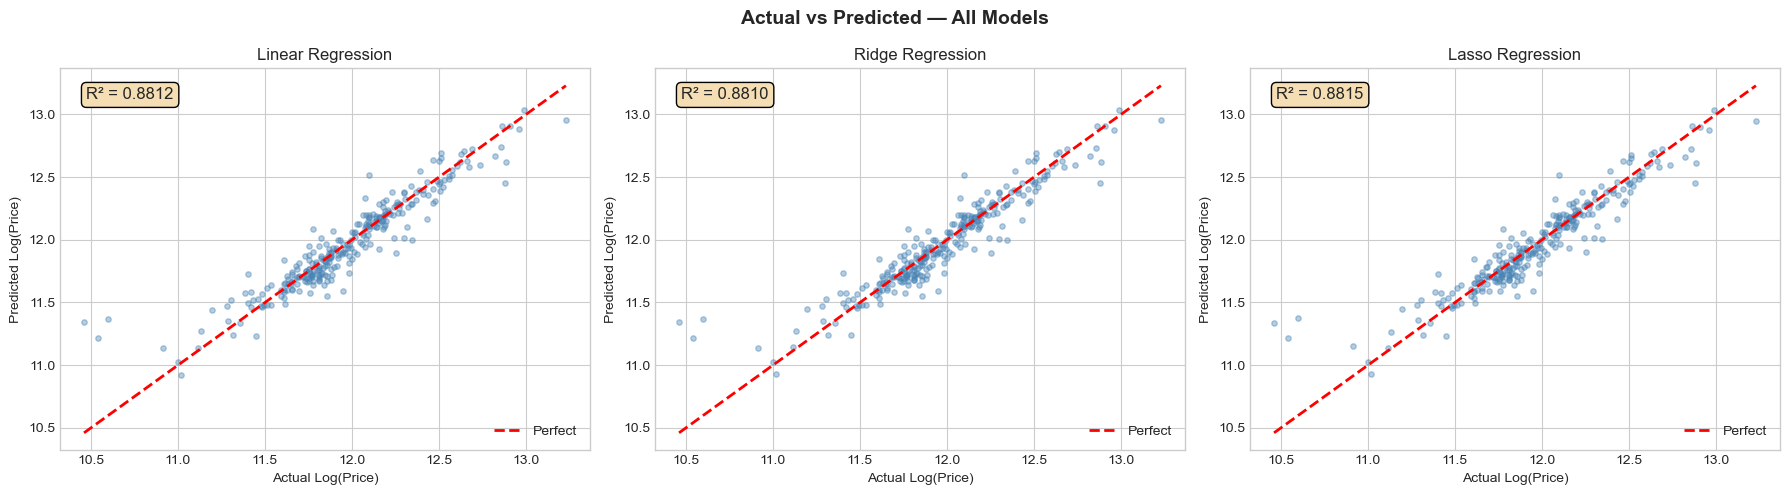

In [100]:
# visualization for Actual and Predicted 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, name in zip(axes,
                            [lr_preds, ridge_preds, lasso_preds],
                            ['Linear Regression', 'Ridge Regression', 'Lasso Regression']):
    
    # Scatter plot: actual vs predicted
    ax.scatter(y_test, preds, alpha=0.4, s=15, color='steelblue')
    
    # Perfect prediction line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')
    
    # Labels
    ax.set_xlabel('Actual Log(Price)')
    ax.set_ylabel('Predicted Log(Price)')
    ax.set_title(name)
    ax.legend()
    
    # Add R² to plot
    r2 = r2_score(y_test, preds)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
    
    

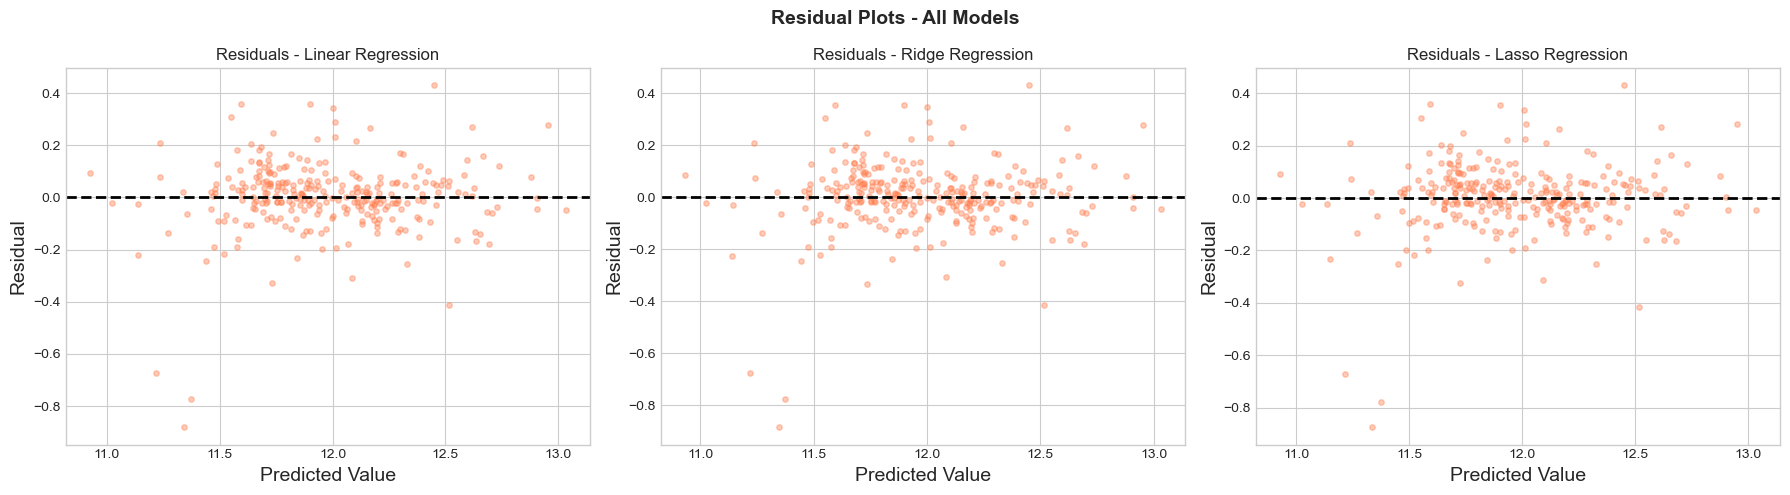

What to look for in residuals : 
Random scatter around 0 = good
Funnel shape = errors grow with predictions (heteroscedasticity)
Curved pattern = relationship is not truly linear


In [101]:
# Residual plots
# A good Model has residuals randomly scattered around 0

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, preds, name in zip(axes,
                          [lr_preds, ridge_preds, lasso_preds],
                           ['Linear Regression', 'Ridge Regression', 'Lasso Regression']) : 
    residuals = y_test.values - preds

    ax.scatter(preds, residuals, alpha=0.4, s=15, color='coral')
    ax.axhline(y=0, color='black', linestyle='--', lw=2)
    ax.set_xlabel('Predicted Value', fontsize=14)
    ax.set_ylabel('Residual', fontsize=14)
    ax.set_title(f'Residuals - {name}')

plt.suptitle('Residual Plots - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('What to look for in residuals : ')
print('Random scatter around 0 = good')
print('Funnel shape = errors grow with predictions (heteroscedasticity)')
print('Curved pattern = relationship is not truly linear')

In [102]:
# Feature Importance (from Ridge coefficeints)
# Which features influence price most?

# Get feature names and their Ridge coefficients
feature_names = X.columns.tolist()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_model.coef_,
    'Abs_Coefficient': np.abs(ridge_model.coef_)
})

# Sort by absolute value
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print('=== TOP 15 MOST IMPORTANT FEATURES (Ridge) ===')
print(coef_df.head(15)[['Feature', 'Coefficient']].to_string())

=== TOP 15 MOST IMPORTANT FEATURES (Ridge) ===
         Feature  Coefficient
3    OverallQual     0.092317
4    OverallCond     0.056200
15     GrLivArea     0.051621
37       TotalSF     0.046605
5      YearBuilt     0.043007
36      HouseAge    -0.042965
13      2ndFlrSF     0.031853
12      1stFlrSF     0.031313
8     BsmtFinSF1     0.028322
2        LotArea     0.026833
6   YearRemodAdd     0.023615
11   TotalBsmtSF     0.023179
25    GarageCars     0.022702
22  TotRmsAbvGrd     0.018901
26    GarageArea     0.018595


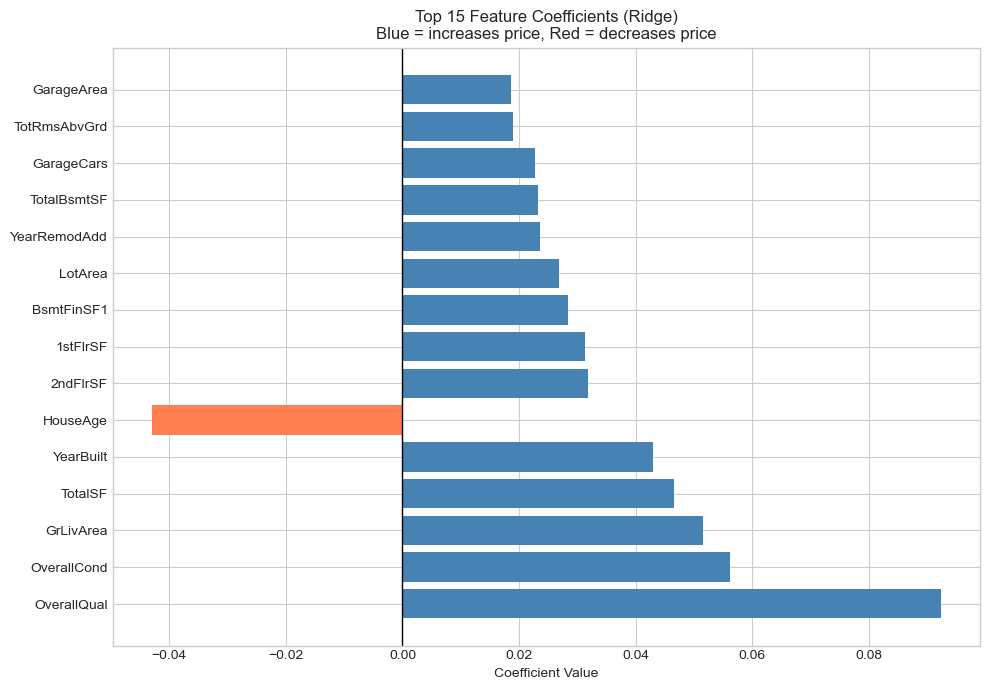

In [103]:
# Visualize top features
top15 = coef_df.head(15)

colors = ['steelblue' if c > 0 else 'coral' for c in top15['Coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(top15['Feature'], top15['Coefficient'], color=colors)
plt.axvline(x=0, color='black', lw=1)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients (Ridge)\nBlue = increases price, Red = decreases price')
plt.tight_layout()
plt.show()

In [104]:
# Make A Real Prediction
# Pick a real house from test set and predict its price 

# Take the first 5 houses from our test set
sample = X_test.head(5)
actual_prices = np.expm1(y_test.head(5).values)  # Convert log price back to dollars

# Scale the sample (same way we scaled training data)
sample_scaled = scaler.transform(sample)

# Predict with Ridge model
log_predictions = ridge_model.predict(sample_scaled)
predicted_prices = np.expm1(log_predictions)  # Convert back from log to dollars

print('=== SAMPLE PREDICTIONS ===')
print(f'{"House":>6}  {"Actual Price":>15}  {"Predicted Price":>15}  {"Difference":>12}')
print('-' * 55)
for i, (actual, predicted) in enumerate(zip(actual_prices, predicted_prices)):
    diff = predicted - actual
    sign = '+' if diff > 0 else ''
    print(f'{i+1:>6}  ${actual:>14,.0f}  ${predicted:>14,.0f}  {sign}${diff:>11,.0f}')

=== SAMPLE PREDICTIONS ===
 House     Actual Price  Predicted Price    Difference
-------------------------------------------------------
     1  $       318,000  $       291,393  $    -26,607
     2  $       144,500  $       146,181  +$      1,681
     3  $       148,500  $       150,113  +$      1,613
     4  $       124,000  $       117,075  $     -6,925
     5  $       128,500  $       122,018  $     -6,482


In [105]:
print('╔══════════════════════════════════════════════════════╗')
print('║           FINAL MODEL COMPARISON                     ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  {"Model":<22} {"Test R²":>8}  {"Test RMSE":>10}    ║')
print('╠══════════════════════════════════════════════════════╣')

for model, preds, name in [
    (lr_model,    lr_preds,    'Linear Regression'),
    (ridge_model, ridge_preds, 'Ridge Regression'),
    (lasso_model, lasso_preds, 'Lasso Regression'),
]:
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f'║  {name:<22} {r2:>8.4f}  {rmse:>10.4f}     ║')

print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║           FINAL MODEL COMPARISON                     ║
╠══════════════════════════════════════════════════════╣
║  Model                   Test R²   Test RMSE    ║
╠══════════════════════════════════════════════════════╣
║  Linear Regression        0.8812      0.1383     ║
║  Ridge Regression         0.8810      0.1384     ║
║  Lasso Regression         0.8815      0.1381     ║
╚══════════════════════════════════════════════════════╝
